# PHIDL 2D Gate Layout Definition

This notebook is used to experiment with and explore the Phidl package which is used to define a 2D gate layout for the QPU. The idea is to elementarise the design which most often is composed of Ohmics, Plunger, and Barrier Gates (and screening gates later on). This would lead to a scalable way to draw and design multi-QD array devices. Furthermore each 2D design can be imported in nextnano++ (a Schrodinger-Poisson solver tool) where we can create a 3D heterostructure off of the 2D layout. The next step would be to link the calculated electrostatics and quantum densities for the heterostructure to experimental parameters and close the design loop with an appropriate loss function to be optimised.

## 0. Imports

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path("../../src").resolve()))

from phidl import Device, quickplot as qp

from qd_design import (
    GateType,
    BARRIER,
    PLUNGER,
    OHMIC,
    SENSOR,
    SCREENING,
    ComponentMetadata,
    BarrierGate,
    PlungerGate,
    OhmicContact,
    SensorGate,
    ScreeningGate,
    SingleDotDevice,
    LinearDotArrayDevice,
    place_right_of,
)

In [2]:
print("Imports worked.")
print("Project src path added:", Path("../../src").resolve())

Imports worked.
Project src path added: /Users/robertjovanov/code/qpu-design-automation-toolkit/src


## 1. Component Instantiation

### - Instantiate Barrier Gate

In [3]:
barrier_meta = ComponentMetadata(
    name="B1",
    gate_type=GateType.BARRIER,
    layer=BARRIER,
    voltage_label="V_B1",
)

barrier = BarrierGate(
    metadata=barrier_meta,
    width_nm=20.0,
    length_nm=100.0,
)

print(barrier.summary())

{'name': 'B1', 'gate_type': 'barrier', 'layer_name': 'barrier', 'gds_layer': 2, 'gds_datatype': 0, 'voltage_label': 'V_B1', 'role': None, 'z_bottom_nm': None, 'z_top_nm': None, 'notes': None, 'params': {'width_nm': 20.0, 'length_nm': 100.0}}


### - Instantiate Plunger Gate

In [4]:
plunger_meta = ComponentMetadata(
    name="P1",
    gate_type=GateType.PLUNGER,
    layer=PLUNGER,
    voltage_label="V_P1",
)

plunger = PlungerGate(
    metadata=plunger_meta,
    body_width_nm=40.0,
    body_length_nm=80.0,
    head_top_width_nm=60.0,
    head_max_width_nm=100.0,
    head_height_nm=100.0,
    upper_taper_height_nm=30.0,
    lower_taper_height_nm=35.0,
)

print(plunger.summary())

{'name': 'P1', 'gate_type': 'plunger', 'layer_name': 'plunger', 'gds_layer': 1, 'gds_datatype': 0, 'voltage_label': 'V_P1', 'role': None, 'z_bottom_nm': None, 'z_top_nm': None, 'notes': None, 'params': {'body_width_nm': 40.0, 'body_length_nm': 80.0, 'head_top_width_nm': 60.0, 'head_max_width_nm': 100.0, 'head_height_nm': 100.0, 'upper_taper_height_nm': 30.0, 'lower_taper_height_nm': 35.0}}


### - Instantiate Ohmic Contact

In [5]:
ohmic_meta = ComponentMetadata(
    name="OC1",
    gate_type=GateType.OHMIC,
    layer=OHMIC,
    voltage_label="V_OC1",
)

ohmic = OhmicContact(
    metadata=ohmic_meta,
    width_nm=40.0,
    length_nm=140.0,
)

print(ohmic.summary())

{'name': 'OC1', 'gate_type': 'ohmic', 'layer_name': 'ohmic', 'gds_layer': 3, 'gds_datatype': 0, 'voltage_label': 'V_OC1', 'role': None, 'z_bottom_nm': None, 'z_top_nm': None, 'notes': None, 'params': {'width_nm': 40.0, 'length_nm': 140.0}}


### - Instantiate Screening Gate

In [3]:
screen_meta = ComponentMetadata(
    name="SG1",
    gate_type=GateType.SCREENING,
    layer=SCREENING,
    voltage_label="V_SG1",
)

screen = ScreeningGate(
    metadata=screen_meta,
    width_nm=40.0,
    length_nm=200.0,
)

print(screen.summary())

{'name': 'SG1', 'gate_type': 'screening', 'layer_name': 'screening', 'gds_layer': 5, 'gds_datatype': 0, 'voltage_label': 'V_SG1', 'role': None, 'z_bottom_nm': None, 'z_top_nm': None, 'notes': None, 'params': {'width_nm': 40.0, 'length_nm': 200.0}}


### - Build Verification

In [6]:
print("Barrier bbox:", barrier.bbox())
print("Plunger bbox:", plunger.bbox())
print("Ohmic bbox:", ohmic.bbox())

Barrier bbox: (np.float64(0.0), np.float64(-50.0), np.float64(20.0), np.float64(50.0))
Plunger bbox: (np.float64(-50.0), np.float64(0.0), np.float64(50.0), np.float64(180.0))
Ohmic bbox: (np.float64(0.0), np.float64(-70.0), np.float64(40.0), np.float64(70.0))


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


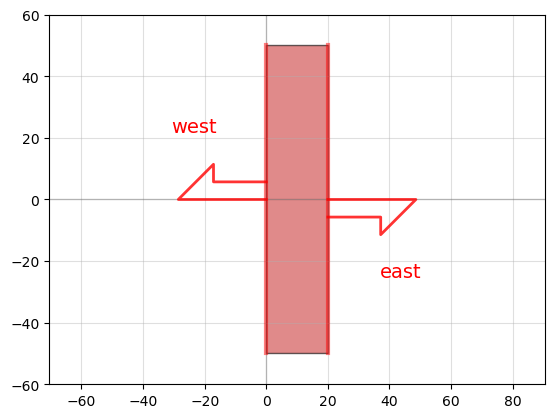

In [7]:
qp(barrier.ensure_built())

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


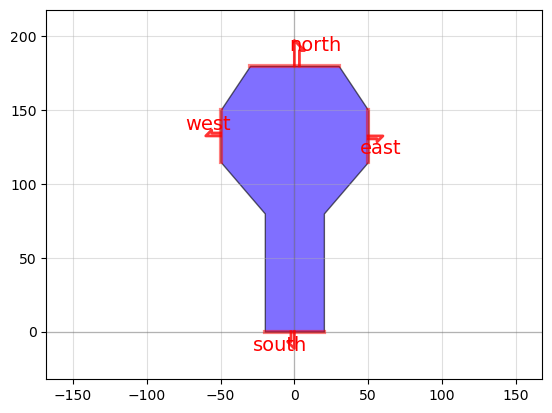

In [8]:
qp(plunger.ensure_built())

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


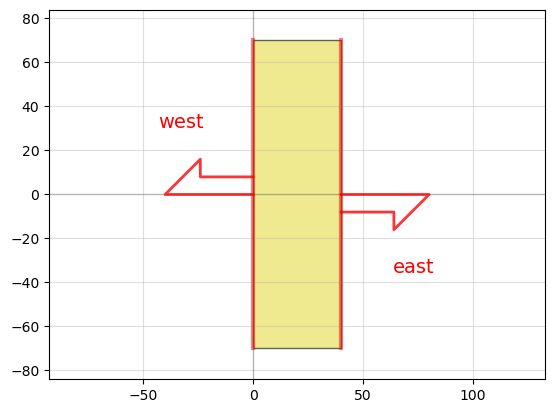

In [9]:
qp(ohmic.ensure_built())

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


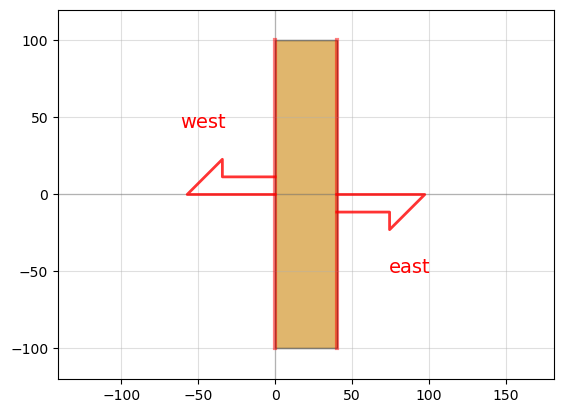

In [4]:
qp(screen.ensure_built())

## 2. Singe QD Device (MVP)

### - Assemble Device

The dimensions specified here are targeted at reproducing the nextnano sketch.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


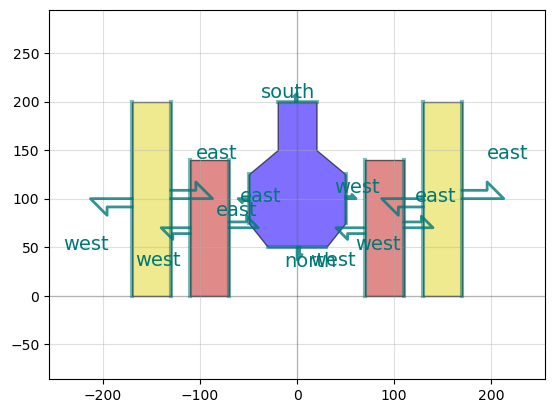

{'name': 'single_dot_mvp_exact', 'device_y_size_nm': 200.0, 'ohmic_width_nm': 40.0, 'ohmic_length_nm': 200.0, 'barrier_width_nm': 40.0, 'barrier_length_nm': 140.0, 'plunger_body_width_nm': 40.0, 'plunger_body_length_nm': 50.0, 'plunger_head_top_width_nm': 60.0, 'plunger_head_max_width_nm': 100.0, 'plunger_head_height_nm': 100.0, 'plunger_upper_taper_height_nm': 25.0, 'plunger_lower_taper_height_nm': 25.0, 'ohmic_to_barrier_gap_nm': 20.0, 'barrier_to_plunger_gap_nm': 20.0}


In [10]:
single_dot = SingleDotDevice(
    name="single_dot_mvp_exact",
    device_y_size_nm=200.0,
    ohmic_width_nm=40.0,
    ohmic_length_nm=200.0,
    barrier_width_nm=40.0,
    barrier_length_nm=140.0,
    plunger_body_width_nm=40.0,
    plunger_body_length_nm=50.0,
    plunger_head_top_width_nm=60.0,
    plunger_head_max_width_nm=100.0,
    plunger_head_height_nm=100.0,
    plunger_upper_taper_height_nm=25.0,
    plunger_lower_taper_height_nm=25.0,
    ohmic_to_barrier_gap_nm=20.0,
    barrier_to_plunger_gap_nm=20.0,
)

layout = single_dot.ensure_built()
qp(layout)

print(single_dot.summary())

### - Export Device GDS and SVG

In [11]:
output_path = Path("../../data/gds")
output_path.mkdir(parents=True, exist_ok=True)

single_dot.write_gds(str(output_path / "single_dot_device.gds"))
single_dot.write_svg(str(output_path / "single_dot_device.svg"))

## 3. 1xN QD Array Device

### - Test: Single QD Device

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


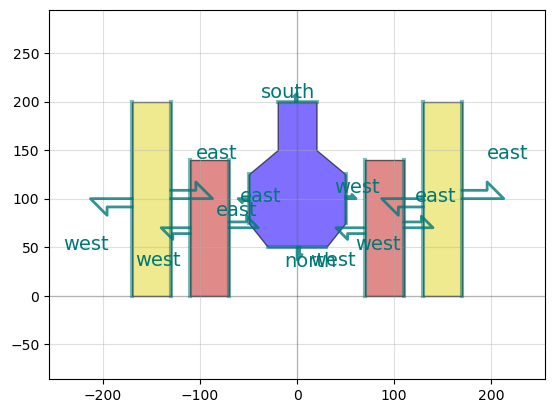

{'name': 'linear_array_1dot', 'n_dots': 1, 'device_y_size_nm': 200.0, 'ohmic_width_nm': 40.0, 'ohmic_length_nm': 200.0, 'barrier_width_nm': 40.0, 'barrier_length_nm': 140.0, 'plunger_body_width_nm': 40.0, 'plunger_body_length_nm': 50.0, 'plunger_head_top_width_nm': 60.0, 'plunger_head_max_width_nm': 100.0, 'plunger_head_height_nm': 100.0, 'plunger_upper_taper_height_nm': 25.0, 'plunger_lower_taper_height_nm': 25.0, 'ohmic_to_barrier_gap_nm': 20.0, 'barrier_to_plunger_gap_nm': 20.0}


In [14]:
linear_1 = LinearDotArrayDevice(
    name="linear_array_1dot",
    n_dots=1,
    device_y_size_nm=200.0,
    ohmic_width_nm=40.0,
    ohmic_length_nm=200.0,
    barrier_width_nm=40.0,
    barrier_length_nm=140.0,
    plunger_body_width_nm=40.0,
    plunger_body_length_nm=50.0,
    plunger_head_top_width_nm=60.0,
    plunger_head_max_width_nm=100.0,
    plunger_head_height_nm=100.0,
    plunger_upper_taper_height_nm=25.0,
    plunger_lower_taper_height_nm=25.0,
    ohmic_to_barrier_gap_nm=20.0,
    barrier_to_plunger_gap_nm=20.0,
)

layout = linear_1.ensure_built()
qp(layout)
print(linear_1.summary())

See the device layout.

In [15]:
for element in linear_1.layout_spec():
    print(element["name"], element["gate_type"], element["x_min_nm"], element["x_max_nm"])

OC_L ohmic -170.0 -130.0
B1 barrier -110.0 -70.0
P1 plunger -50.00000000000002 50.0
B2 barrier 70.0 110.0
OC_R ohmic 130.0 170.0


Save device layout JSON, device GDS file, and device SVG.

In [16]:
output_path = Path("../../data/gds")
output_path.mkdir(parents=True, exist_ok=True)

linear_1.write_gds(str(output_path / "single_dot_device.gds"))
print("Saved GDS.")
linear_1.write_svg(str(output_path / "single_dot_device.svg"))
print("Saved SVG.")
linear_1.write_layout_spec_json(str(output_path / "single_dot_device_layout.json"))
print("Saved JSON layout spec.")

Saved GDS.
Saved SVG.
Saved JSON layout spec.


### - Test: Double QD Device

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


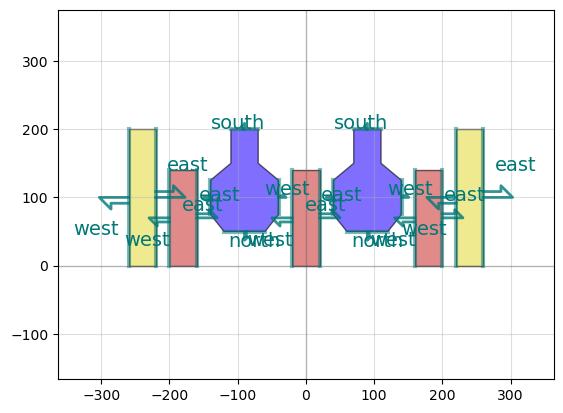

{'name': 'linear_array_2dot', 'n_dots': 2, 'device_y_size_nm': 200.0, 'ohmic_width_nm': 40.0, 'ohmic_length_nm': 200.0, 'barrier_width_nm': 40.0, 'barrier_length_nm': 140.0, 'plunger_body_width_nm': 40.0, 'plunger_body_length_nm': 50.0, 'plunger_head_top_width_nm': 60.0, 'plunger_head_max_width_nm': 100.0, 'plunger_head_height_nm': 100.0, 'plunger_upper_taper_height_nm': 25.0, 'plunger_lower_taper_height_nm': 25.0, 'ohmic_to_barrier_gap_nm': 20.0, 'barrier_to_plunger_gap_nm': 20.0}


In [17]:
linear_2 = LinearDotArrayDevice(
    name="linear_array_2dot",
    n_dots=2,
    device_y_size_nm=200.0,
    ohmic_width_nm=40.0,
    ohmic_length_nm=200.0,
    barrier_width_nm=40.0,
    barrier_length_nm=140.0,
    plunger_body_width_nm=40.0,
    plunger_body_length_nm=50.0,
    plunger_head_top_width_nm=60.0,
    plunger_head_max_width_nm=100.0,
    plunger_head_height_nm=100.0,
    plunger_upper_taper_height_nm=25.0,
    plunger_lower_taper_height_nm=25.0,
    ohmic_to_barrier_gap_nm=20.0,
    barrier_to_plunger_gap_nm=20.0,
)

layout = linear_2.ensure_built()
qp(layout)
print(linear_2.summary())

In [18]:
for element in linear_2.layout_spec():
    print(element["name"], element["gate_type"], element["x_min_nm"], element["x_max_nm"])

OC_L ohmic -260.0 -220.0
B1 barrier -200.0 -160.0
P1 plunger -140.00000000000003 -40.0
B2 barrier -20.0 20.0
P2 plunger 39.99999999999998 140.0
B3 barrier 160.0 200.0
OC_R ohmic 220.0 260.0


In [19]:
output_path = Path("../../data/gds")
output_path.mkdir(parents=True, exist_ok=True)

linear_2.write_gds(str(output_path / "double_dot_device.gds"))
print("Saved GDS.")
linear_2.write_svg(str(output_path / "double_dot_device.svg"))
print("Saved SVG.")
linear_2.write_layout_spec_json(str(output_path / "double_dot_device_layout.json"))
print("Saved JSON layout spec.")

Saved GDS.
Saved SVG.
Saved JSON layout spec.


### - Test: 1x10 QD Array Device

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


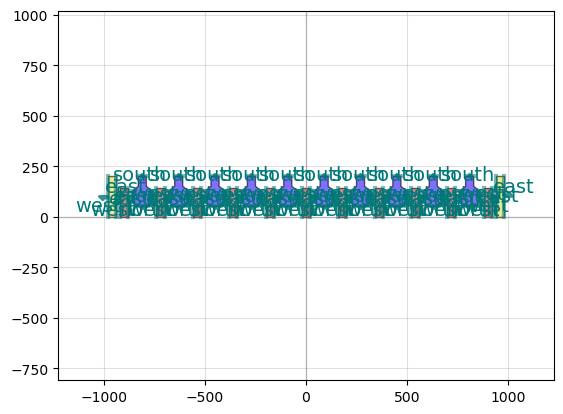

{'name': 'linear_array_10dot', 'n_dots': 10, 'device_y_size_nm': 200.0, 'ohmic_width_nm': 40.0, 'ohmic_length_nm': 200.0, 'barrier_width_nm': 40.0, 'barrier_length_nm': 140.0, 'plunger_body_width_nm': 40.0, 'plunger_body_length_nm': 50.0, 'plunger_head_top_width_nm': 60.0, 'plunger_head_max_width_nm': 100.0, 'plunger_head_height_nm': 100.0, 'plunger_upper_taper_height_nm': 25.0, 'plunger_lower_taper_height_nm': 25.0, 'ohmic_to_barrier_gap_nm': 20.0, 'barrier_to_plunger_gap_nm': 20.0}


In [20]:
linear_10 = LinearDotArrayDevice(
    name="linear_array_10dot",
    n_dots=10,
    device_y_size_nm=200.0,
    ohmic_width_nm=40.0,
    ohmic_length_nm=200.0,
    barrier_width_nm=40.0,
    barrier_length_nm=140.0,
    plunger_body_width_nm=40.0,
    plunger_body_length_nm=50.0,
    plunger_head_top_width_nm=60.0,
    plunger_head_max_width_nm=100.0,
    plunger_head_height_nm=100.0,
    plunger_upper_taper_height_nm=25.0,
    plunger_lower_taper_height_nm=25.0,
    ohmic_to_barrier_gap_nm=20.0,
    barrier_to_plunger_gap_nm=20.0,
)

layout = linear_10.ensure_built()
qp(layout)
print(linear_10.summary())

In [21]:
for element in linear_10.layout_spec():
    print(element["name"], element["gate_type"], element["x_min_nm"], element["x_max_nm"])

OC_L ohmic -980.0 -940.0
B1 barrier -920.0 -880.0
P1 plunger -860.0 -760.0
B2 barrier -740.0 -700.0
P2 plunger -680.0 -580.0
B3 barrier -560.0 -520.0
P3 plunger -500.0 -400.0
B4 barrier -380.0 -340.0
P4 plunger -320.0 -220.0
B5 barrier -200.0 -160.0
P5 plunger -140.00000000000003 -40.0
B6 barrier -20.0 20.0
P6 plunger 39.99999999999998 140.0
B7 barrier 160.0 200.0
P7 plunger 219.99999999999997 320.0
B8 barrier 340.0 380.0
P8 plunger 400.0 500.0
B9 barrier 520.0 560.0
P9 plunger 580.0 680.0
B10 barrier 700.0 740.0
P10 plunger 760.0 860.0
B11 barrier 880.0 920.0
OC_R ohmic 940.0 980.0


In [22]:
output_path = Path("../../data/gds")
output_path.mkdir(parents=True, exist_ok=True)

linear_10.write_gds(str(output_path / "1x10_dot_device.gds"))
print("Saved GDS.")
linear_10.write_svg(str(output_path / "1x10_dot_device.svg"))
print("Saved SVG.")
linear_10.write_layout_spec_json(str(output_path / "1x10_dot_device_layout.json"))
print("Saved JSON layout spec.")

Saved GDS.
Saved SVG.
Saved JSON layout spec.
